<h1>Section A: Data Exploration</h1>

In [2]:
import pandas as pd 

df = pd.read_csv("ecommerce_large.csv")
df

,CustomerID,Age,Gender,PurchaseAmount,Category
0,1,49,F,5483,Electronics
1,2,39,F,7810,Beauty
2,3,46,F,2193,Fashion
3,4,39,M,1069,Electronics
4,5,20,M,1214,Home
...,...,...,...,...,...
495,496,46,F,3336,Beauty
496,497,25,F,3518,Home
497,498,58,F,2982,Electronics
498,499,36,M,9382,Home


In [6]:
# Q1 Load dataset and inspect:

#Shape
#Columns
#Data types 

df.shape 
df.columns.tolist() 
df.dtypes

CustomerID         int64
Age                int64
Gender            object
PurchaseAmount     int64
Category          object
dtype: object

In [12]:
# Q2 Check:

#Missing values
#Duplicate records 

df.isnull()
df.duplicated

<bound method DataFrame.duplicated of      CustomerID  Age Gender  PurchaseAmount     Category
0             1   49      F            5483  Electronics
1             2   39      F            7810       Beauty
2             3   46      F            2193      Fashion
3             4   39      M            1069  Electronics
4             5   20      M            1214         Home
..          ...  ...    ...             ...          ...
495         496   46      F            3336       Beauty
496         497   25      F            3518         Home
497         498   58      F            2982  Electronics
498         499   36      M            9382         Home
499         500   56      M            7857  Electronics

[500 rows x 5 columns]>

<h1>Section B: Customer Analysis</h1>

In [17]:
# Q3 Calculate:

#Total Revenue
#Average Purchase Amount
#Maximum Purchase Amount
#Minimum Purchase Amount 

df["PurchaseAmount"].agg(["sum","mean","max","min"]) # correct 
#df.groupby("PurchaseAmount").agg(["sum","mean","max","min"]) 
# Mistake 1: Wrong column for grouping

# Aap PurchaseAmount ko groupby key bana rahe ho, jo usually galat hota hai.

# PurchaseAmount ek numeric transaction value hota hai
# Groupby ke liye usually categorical column hota hai, like:
# CustomerID
# Product
# Category

sum     2439236.000
mean       4878.472
max        9988.000
min         202.000
Name: PurchaseAmount, dtype: float64

In [23]:
# Q4 Find:

# Highest Spending Customer
# Top 10 Customers 

df.groupby("CustomerID")["PurchaseAmount"].sum().idxmax()

np.int64(338)

In [24]:
# Q5 Find average purchase amount by:

#Gender
#Category 

df["PurchaseAmount"].agg({"Gender" : "mean" , 
                         "Category" : "mean"
                         })

Gender      4878.472
Category    4878.472
Name: PurchaseAmount, dtype: float64

<h1>Section C: Feature Engineering</h1>

In [25]:
# Q6 Create Age Groups:

#18-25
#26-35
#36-45
#46+ 

df["Age_Groups"] = pd.cut(df["Age"], bins=[18, 25, 35, 45, 100] , labels=["18-25","26-35","36-45", "46+"]) 
print(df)


     CustomerID  Age Gender  PurchaseAmount     Category Age_Groups
0             1   49      F            5483  Electronics        46+
1             2   39      F            7810       Beauty      36-45
2             3   46      F            2193      Fashion        46+
3             4   39      M            1069  Electronics      36-45
4             5   20      M            1214         Home      18-25
..          ...  ...    ...             ...          ...        ...
495         496   46      F            3336       Beauty        46+
496         497   25      F            3518         Home      18-25
497         498   58      F            2982  Electronics        46+
498         499   36      M            9382         Home      36-45
499         500   56      M            7857  Electronics        46+

[500 rows x 6 columns]


In [28]:
#Q7 Find spending by age group. 
df.groupby("Age_Groups")["PurchaseAmount"].sum()


C:\Users\hp\AppData\Local\Temp\ipykernel_9792\495477713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Groups")["PurchaseAmount"].sum()


Age_Groups
18-25    362514
26-35    574488
36-45    622968
46+      807273
Name: PurchaseAmount, dtype: int64

<h1>Section D: GroupBy Analysis</h1> 

In [31]:
#Q8 Category-wise:

#Total Revenue
#Average Purchase
#Customer Count 

df.groupby("Category").agg({
    "PurchaseAmount" : "sum",
    "PurchaseAmount": "mean",
    "CustomerID" : "nunique"
})


,PurchaseAmount,CustomerID
Category,,
Beauty,5294.798387,124
Electronics,4817.445312,128
Fashion,4926.701754,114
Home,4510.477612,134


In [32]:
# Q9 Gender-wise:

#Total Revenue
#Average Purchase 

df.groupby("Gender").agg({
    "PurchaseAmount" : "sum",
    "PurchaseAmount": "mean"
})

,PurchaseAmount
Gender,
F,4903.181435
M,4856.205323


<h1>Section E: Visualization</h1>

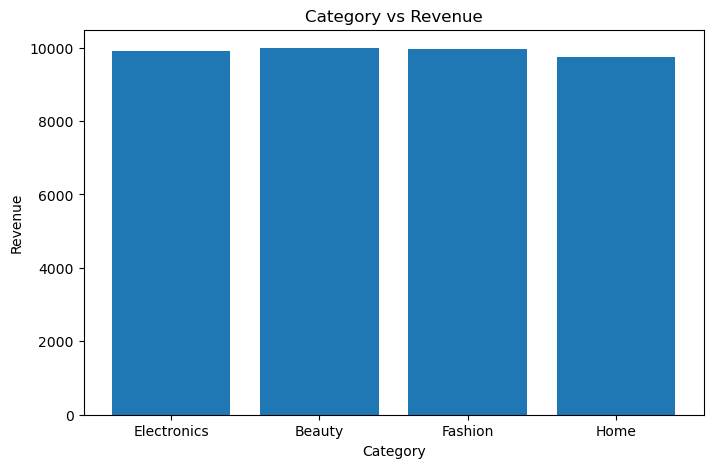

In [33]:
# Chart 1 : Bar Chart
# Category vs Revenue 

import matplotlib.pyplot as plt 
plt.figure(figsize=(8,5))
plt.bar(df["Category"], df["PurchaseAmount"])
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.title("Category vs Revenue")
plt.show()


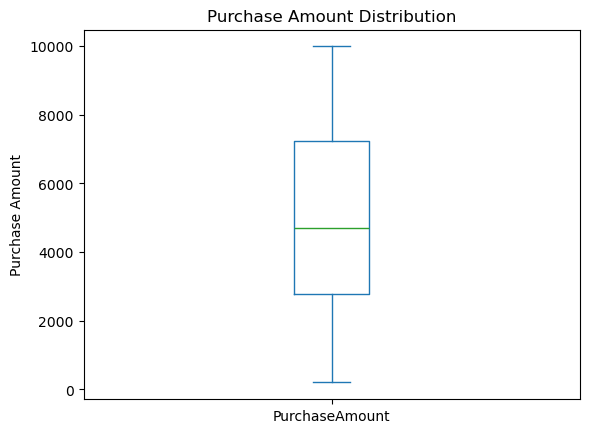

In [34]:
# Chart 2 Box Plot
# Purchase Amount Distribution 

import matplotlib.pyplot as plt

df["PurchaseAmount"].plot(kind="box")
plt.title("Purchase Amount Distribution")
plt.ylabel("Purchase Amount")
plt.show()


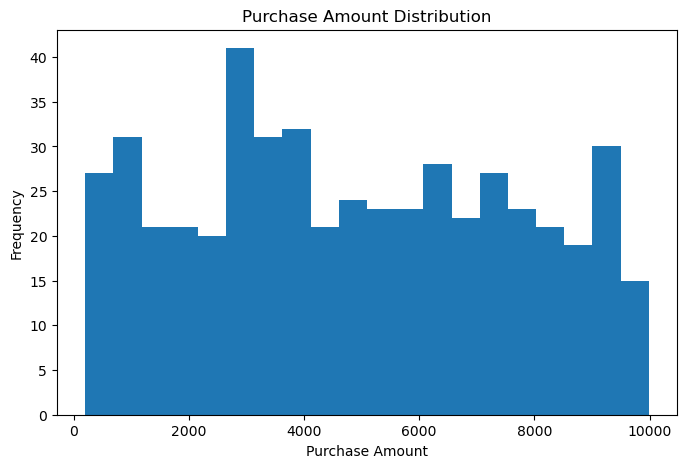

In [35]:
# Chart 4 Histogram
#Purchase Amount Distribution 
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["PurchaseAmount"],bins=20)
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.title("Purchase Amount Distribution")
plt.show()

